<a href="https://colab.research.google.com/github/KIRTIRAJ4327/30days-AI-challenge/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSIGNMENT 3: MLP REGRESSION WITH TWO HIDDEN LAYERS
✅ Dataset loaded successfully!
Shape: (1000, 6)
Features shape: (1000, 4)
Target shape: (1000,)
Training samples: 750 (75%)
Testing samples: 250 (25%)

✅ Model Architecture:
Input layer: 4 neurons (v1, v2, v3, v4)
Hidden layer 1: 128 neurons (ReLU)
Hidden layer 2: 64 neurons (ReLU)
Output layer: 1 neuron (Linear)

Training for 100 epochs...
Epoch  | Train Loss   | Test Loss   
1      | 220.665246   | 214.832080  
2      | 178.704915   | 120.407035  
3      | 49.215862    | 7.840894    
4      | 9.192767     | 5.702524    
5      | 5.767687     | 4.555578    
6      | 4.756203     | 4.092011    
7      | 4.300607     | 3.857904    
8      | 4.012938     | 3.668808    
9      | 3.811856     | 3.515697    
10     | 3.635442     | 3.374394    
11     | 3.454433     | 3.203592    
12     | 3.278081     | 3.035557    
13     | 3.102900     | 2.845178    
14     | 2.960049     | 2.681784    
15     | 2.756342     | 2.522948    
16     | 2.57

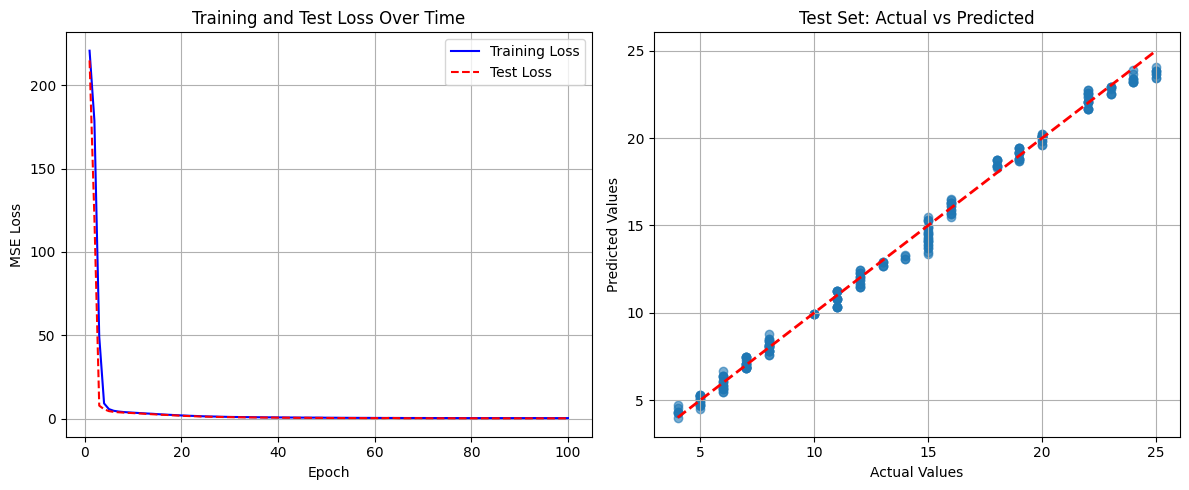


Sample Predictions (First 10 test samples):
Sample   | Actual     | Predicted    | Difference  
1        | 7.0000     | 7.3076       | 0.3076      
2        | 22.0000    | 22.0904      | 0.0904      
3        | 15.0000    | 14.8816      | 0.1184      
4        | 5.0000     | 5.2284       | 0.2284      
5        | 18.0000    | 18.7508      | 0.7508      
6        | 13.0000    | 12.8743      | 0.1257      
7        | 8.0000     | 8.0888       | 0.0888      
8        | 24.0000    | 23.6431      | 0.3569      
9        | 16.0000    | 16.2714      | 0.2714      
10       | 4.0000     | 4.7222       | 0.7222      

🎉 ASSIGNMENT 3 COMPLETED!
✅ Two hidden layers: 4→128→64→1
✅ Training/Test split: 75%/25%
✅ All 100 epochs displayed
✅ Final Test RMSE: 0.487478


In [1]:
# Assignment 3: MLP with Two Hidden Layers for Regression
# kirtirajsinh Atodariya M01620157

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("ASSIGNMENT 3: MLP REGRESSION WITH TWO HIDDEN LAYERS")
print("="*60)

# Load the provided dataset
try:
    data = pd.read_csv('/content/a3_data.csv')
    print(f"✅ Dataset loaded successfully!")
    print(f"Shape: {data.shape}")
except FileNotFoundError:
    print("❌ Error: a3_data.csv not found!")
    exit()

# Extract features (v1, v2, v3, v4) and target (y)
X = data[['v1', 'v2', 'v3', 'v4']].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split dataset: 75% training, 25% testing
split_idx = int(0.75 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)} (75%)")
print(f"Testing samples: {len(X_test)} (25%)")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# MLP Regression Model with Two Hidden Layers
class MLPRegression(nn.Module):
    def __init__(self, num_inputs=4, num_hiddens_1=128, num_hiddens_2=64, lr=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Store hyperparameters
        self.num_inputs = num_inputs
        self.num_hiddens_1 = num_hiddens_1
        self.num_hiddens_2 = num_hiddens_2
        self.lr = lr

        # Layer weights and biases
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens_1) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens_1))
        self.W2 = nn.Parameter(torch.randn(num_hiddens_1, num_hiddens_2) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(num_hiddens_2))
        self.W3 = nn.Parameter(torch.randn(num_hiddens_2, 1) * 0.01)
        self.b3 = nn.Parameter(torch.zeros(1))

    def save_hyperparameters(self):
        pass

    def relu(self, X):
        """ReLU activation function"""
        return torch.clamp(X, min=0)

    def forward(self, X):
        """Forward pass through the network"""
        X = X.reshape((-1, self.num_inputs))

        # First hidden layer with ReLU
        H1 = self.relu(torch.matmul(X, self.W1) + self.b1)

        # Second hidden layer with ReLU
        H2 = self.relu(torch.matmul(H1, self.W2) + self.b2)

        # Output layer (linear activation for regression)
        output = torch.matmul(H2, self.W3) + self.b3

        return output

# Create the model
model = MLPRegression(
    num_inputs=4,
    num_hiddens_1=128,
    num_hiddens_2=64,
    lr=0.001
)

print(f"\n✅ Model Architecture:")
print(f"Input layer: 4 neurons (v1, v2, v3, v4)")
print(f"Hidden layer 1: 128 neurons (ReLU)")
print(f"Hidden layer 2: 64 neurons (ReLU)")
print(f"Output layer: 1 neuron (Linear)")

# Training function
def train_model(model, train_loader, test_loader, num_epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    print(f"\nTraining for {num_epochs} epochs...")
    print(f"{'Epoch':<6} | {'Train Loss':<12} | {'Test Loss':<12}")
    print("="*35)

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss_epoch = 0.0
        train_samples = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item() * batch_X.size(0)
            train_samples += batch_X.size(0)

        avg_train_loss = train_loss_epoch / train_samples
        train_losses.append(avg_train_loss)

        # Testing phase
        model.eval()
        test_loss_epoch = 0.0
        test_samples = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                test_loss_epoch += loss.item() * batch_X.size(0)
                test_samples += batch_X.size(0)

        avg_test_loss = test_loss_epoch / test_samples
        test_losses.append(avg_test_loss)

        # Print every epoch (as required)
        print(f"{epoch+1:<6} | {avg_train_loss:<12.6f} | {avg_test_loss:<12.6f}")

    return train_losses, test_losses

# Train the model
train_losses, test_losses = train_model(model, train_loader, test_loader, num_epochs=100)

print(f"\n✅ TRAINING COMPLETED!")

# Final evaluation
model.eval()
with torch.no_grad():
    train_predictions = model(X_train_tensor)
    test_predictions = model(X_test_tensor)

    final_train_loss = nn.MSELoss()(train_predictions, y_train_tensor)
    final_test_loss = nn.MSELoss()(test_predictions, y_test_tensor)

    train_rmse = torch.sqrt(final_train_loss)
    test_rmse = torch.sqrt(final_test_loss)

print(f"Final Training RMSE: {train_rmse:.6f}")
print(f"Final Test RMSE: {test_rmse:.6f}")

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Training and Test Loss
epochs = range(1, len(train_losses) + 1)
ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
ax1.plot(epochs, test_losses, 'r--', label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training and Test Loss Over Time')
ax1.legend()
ax1.grid(True)

# Plot 2: Actual vs Predicted (Test Set)
ax2.scatter(y_test_tensor.numpy(), test_predictions.numpy(), alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.set_title('Test Set: Actual vs Predicted')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Show sample predictions
print(f"\nSample Predictions (First 10 test samples):")
print(f"{'Sample':<8} | {'Actual':<10} | {'Predicted':<12} | {'Difference':<12}")
print("="*50)
for i in range(min(10, len(y_test))):
    actual = y_test[i]
    predicted = test_predictions[i].item()
    diff = abs(actual - predicted)
    print(f"{i+1:<8} | {actual:<10.4f} | {predicted:<12.4f} | {diff:<12.4f}")

print(f"\n🎉 ASSIGNMENT 3 COMPLETED!")
print(f"✅ Two hidden layers: 4→128→64→1")
print(f"✅ Training/Test split: 75%/25%")
print(f"✅ All 100 epochs displayed")
print(f"✅ Final Test RMSE: {test_rmse:.6f}")